In [27]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("newnguyn/steam-game-clean")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'steam-game-clean' dataset.
Path to dataset files: /kaggle/input/steam-game-clean


Lettura del file *SteamGames.csv*, contenente dati relativi ai giochi presenti sulla piattaforma Steam. Vengon effettuati controlli per la presenza di duplicati o valori nulli.

In [28]:
import pandas as pd
import numpy as np

csv_path = path + "/SteamGames.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nTipi di dato:")
print(df.dtypes)

print("\nValori mancanti:")
print(df.isnull().sum())


print("\nDuplicati completi:", df.duplicated().sum())
print("AppID duplicati:", df["Appid"].duplicated().sum())



Shape: (29931, 18)

Tipi di dato:
Appid                 int64
Name                 object
Type                 object
ReleaseDate          object
Genres               object
Developers           object
Publishers           object
Description          object
price                object
Thumbnail            object
Tags                 object
ReviewScore           int64
PositiveReview        int64
NegativeReview        int64
OsRequirement        object
MemoryRequirement    object
CpuRequirement       object
Rank                  int64
dtype: object

Valori mancanti:
Appid                   0
Name                    0
Type                    0
ReleaseDate            14
Genres                413
Developers             26
Publishers           1045
Description            52
price                   0
Thumbnail               0
Tags                 1614
ReviewScore             0
PositiveReview          0
NegativeReview          0
OsRequirement        2937
MemoryRequirement    3984
CpuRequirement

Fase di pulizia dei dati, in particolare:
* La data di pubblicazione è stata convertita in un formarto "Anno-Mese-Giorno".
* Il prezzo è stato convertito in un valore numerico, rimuovendo il simbolo del dollaro.
* Rimossa la colonna `Thumbnail`, poco utile per il compito.

Per quanto riguarda la gesitone dei **valori mancanti**, le decisioni prese sono state le seguenti:
1. **Genres (410 nulli):** i valori mancanti sono stati sostituiti con il genere statisticamente prevalente nel marketplace di Steam (`"Indie"`).
2. **Requisiti hardware (MemoryRequirement, 3967 nulli):** il sistema calcola la **RAM mediana** incrociando il genere del gioco e la sua macro-fascia di prezzo (*Price Tier*). In base alla RAM stimata o reale, vengono allineati a cascata i requisiti di **CPU** e **OS** (es. se la RAM stimata è $\ge 12\text{ GB}$, vengono automaticamente iniettati profili coerenti come `High-End Modern CPU` e `Windows 10/11 64-bit`)..
3. **Colonne testuali (Publishers, Developers, Tags, Description):** i valori nulli sono stati standardizzati con stringhe costanti (es. `"Unknown"`, `"No Description"`).
4. **ReleaseDate (15 nulli):** sostituiti con una data fittizia standardizzata per ragioni di consistenza del tipo di dato (Dtype).



In [29]:
import numpy as np
import pandas as pd
import re

# Parsing delle date e del prezzo
df["ReleaseDate"] = pd.to_datetime(df["ReleaseDate"], errors="coerce")
df["price"] = df["price"].astype(str).str.replace("$", "", regex=False)
df["price"] = pd.to_numeric(df["price"], errors="coerce").fillna(0.0)

df = df.drop(columns=["Thumbnail"], errors="ignore")

# Gestione del genere (estrazione genere primario per il raggruppamento)
df["Genres"] = df["Genres"].fillna("Indie")
df["Primary_Genre"] = df["Genres"].apply(
    lambda x: x.split(",")[0].strip() if isinstance(x, str) else "Indie"
)

# Estrazione dei numeri dalla stringa MemoryRequirement per creare una colonna temporanea numerica
df["Memory_GB_Temp"] = (
    df["MemoryRequirement"]
    .str.extract(r"(\d+)\s*(?:GB|gb|Gb|RAM|ram)")
    .astype(float)
)


# Definizione delle macro-fasce di prezzo
def assegna_fascia_prezzo(p):
    if p == 0:
        return "Free"
    elif p <= 15:
        return "Budget"
    elif p <= 40:
        return "Mid_Tier"
    else:
        return "Premium_AAA"


df["Price_Tier"] = df["price"].apply(assegna_fascia_prezzo)

# Calcolo delle mediane di RAM raggruppando per genere primario e fascia di prezzo
mediane_ram = (
    df.groupby(["Primary_Genre", "Price_Tier"])["Memory_GB_Temp"]
    .median()
    .fillna(4.0)
)


# Funzione di imputazione e sincronizzazione hardware
def imputa_hardware_coerente(row):
    # Determina i GB di RAM (reali o stimati)
    ram_corrente = row["Memory_GB_Temp"]
    if pd.isna(ram_corrente) or ram_corrente == 0:
        chiave = (row["Primary_Genre"], row["Price_Tier"])
        ram_stata = (
            mediane_ram[chiave] if chiave in mediane_ram.index else 4.0
        )
        ram_finale = int(ram_stata)
    else:
        ram_finale = int(ram_corrente)

    # Sincronizzazione euristica di CPU e OS basata sulla RAM finale
    # Profilo HIGH-END (Es. Giochi pesanti moderni)
    if ram_finale >= 12:
        cpu_stimata = "High-End Modern CPU (Intel i7 / Ryzen 7)"
        os_stimato = "Windows 10/11 (64-bit)"
    # Profilo MID-TIER (Es. Standard di mercato)
    elif ram_finale >= 8:
        cpu_stimata = "Mid-Range CPU (Intel i5 / Ryzen 5)"
        os_stimato = "Windows 10 (64-bit)"
    # Profilo LOW-END / INDIE LEGGERO
    else:
        cpu_stimata = "Entry-Level CPU (Intel i3 / Core 2 Duo)"
        os_stimato = "Windows 7/8/10 (64-bit)"

    mem_req = (
        f"{ram_finale} GB RAM"
        if pd.isna(row["MemoryRequirement"]) or "0 GB" in str(row["MemoryRequirement"])
        else row["MemoryRequirement"]
    )
    cpu_req = (
        cpu_stimata
        if pd.isna(row["CpuRequirement"]) or str(row["CpuRequirement"]).strip() == ""
        else row["CpuRequirement"]
    )
    os_req = (
        os_stimato
        if pd.isna(row["OsRequirement"]) or str(row["OsRequirement"]).strip() == ""
        else row["OsRequirement"]
    )

    return pd.Series([mem_req, cpu_req, os_req])


# Sincronizzazione hardware in parallelo sulle tre colonne
df[["MemoryRequirement", "CpuRequirement", "OsRequirement"]] = df.apply(
    imputa_hardware_coerente, axis=1
)

# Pulizia colonne di servizio temporanee
df = df.drop(columns=["Memory_GB_Temp", "Price_Tier"])

df["Publishers"] = df["Publishers"].fillna("Unknown")
df["Developers"] = df["Developers"].fillna("Unknown")
df["Tags"] = df["Tags"].fillna("Unknown")
df["Description"] = df["Description"].fillna("No Description")
df["ReleaseDate"] = df["ReleaseDate"].fillna(pd.to_datetime("2026-01-01"))

print("\nShape dopo pulizia hardware simmetrica:", df.shape)
display(df.head())


Shape dopo pulizia hardware simmetrica: (29931, 18)


,Appid,Name,Type,ReleaseDate,Genres,Developers,Publishers,Description,price,Tags,ReviewScore,PositiveReview,NegativeReview,OsRequirement,MemoryRequirement,CpuRequirement,Rank,Primary_Genre
0,3764200,Resident Evil Requiem,game,2026-02-26,"Action,Adventure","CAPCOM Co., Ltd.","CAPCOM Co., Ltd.",Resident Evil Requiem Deluxe Edition Resident ...,69.99,Unknown,9,23715,793,Windows 10 (64-bit),8 GB RAM,Mid-Range CPU (Intel i5 / Ryzen 5),1,Action
1,730,Counter-Strike 2,game,2012-08-21,"Action,Free To Play",Valve,Valve,"For over two decades, Counter-Strike has offer...",0.00,"FPS,Shooter,Multiplayer,Competitive,Action,Tea...",8,1214897,202393,Windows® 10,8 GB RAM,4 hardware CPU threads - Intel® Core™ i5 750 o...,2,Action
2,1808500,ARC Raiders,game,2025-10-30,Action,Embark Studios,Embark Studios,ARC Raiders Deluxe Edition ARC Raiders Deluxe ...,39.99,"Extraction Shooter,Multiplayer,PvP,PvE,Third-P...",8,149531,23194,Windows 10 or later 64-bit (latest update),12 GB RAM,Intel Core i5-6600K or AMD Ryzen R5 1600 proce...,3,Action
3,359550,Tom Clancy's Rainbow Six Siege,game,2015-12-01,"Action,Free To Play",Ubisoft Montreal,Ubisoft,Season 11 Year 1 Overview Year 11 Roadmap Free...,0.00,Unknown,8,522886,106839,Windows 7/8/10 (64-bit),4 GB RAM,Entry-Level CPU (Intel i3 / Core 2 Duo),4,Action
4,1172470,Apex Legends™,game,2020-11-04,"Action,Adventure,Free To Play",Respawn,Electronic Arts,Apex Legends: Breach About the Game Conquer wi...,0.00,"Free to Play,Multiplayer,Battle Royale,FPS,Sho...",6,820,216,64-bit Windows 10,6 GB RAM,"AMD FX 4350 or Equivalent, Intel Core i3 6300 ...",5,Action


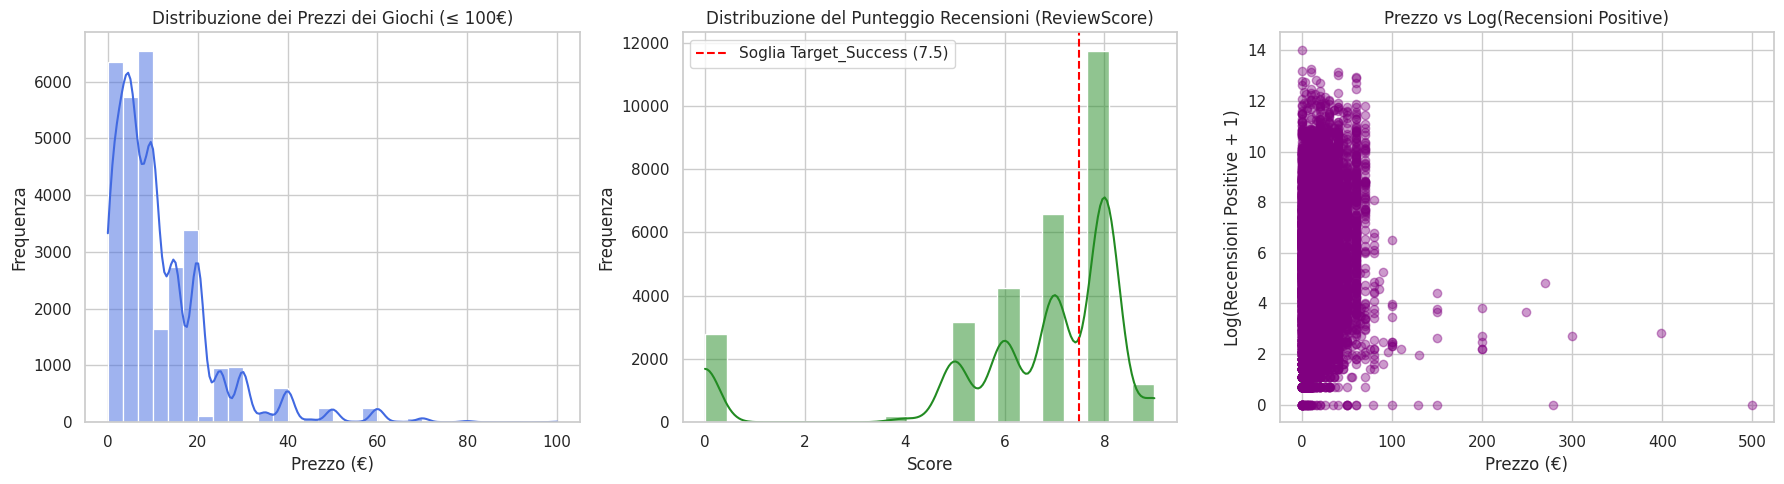


 [STATISTICHE CHIAVE DEL DATASET]:
-> Numero totale di giochi censiti: 29931
-> Prezzo Medio di un gioco: 11.83€ (Max: 499.00€)
-> Punteggio Recensioni Medio: 6.45/10
-> Gioco più popolare (Più recensioni positive): 'Counter-Strike 2' con 1,214,897 recensioni.


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configurazione dello stile dei grafici
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# Distribuzione dei prezzi (sotto i 100€ per evitare outlier estremi)
plt.subplot(1, 3, 1)
prezzi_filtrati = df[df['price'] <= 100]['price'].dropna()
sns.histplot(prezzi_filtrati, bins=30, kde=True, color="royalblue")
plt.title("Distribuzione dei Prezzi dei Giochi (≤ 100€)")
plt.xlabel("Prezzo (€)")
plt.ylabel("Frequenza")

# Distribuzione del ReviewScore
plt.subplot(1, 3, 2)
sns.histplot(df['ReviewScore'].dropna(), bins=20, kde=True, color="forestgreen")
plt.axvline(x=7.5, color='red', linestyle='--', label='Soglia Target_Success (7.5)')
plt.title("Distribuzione del Punteggio Recensioni (ReviewScore)")
plt.xlabel("Score")
plt.ylabel("Frequenza")
plt.legend()

# Correlazione logaritmica tra recensioni positive e prezzo
plt.subplot(1, 3, 3)
# Usiamo la scala logaritmica perché le recensioni vanno da zero a milioni, schiacciando il grafico
df_plot = df.dropna(subset=['PositiveReview', 'price'])
plt.scatter(df_plot['price'], np.log1p(df_plot['PositiveReview']), alpha=0.4, color="purple")
plt.title("Prezzo vs Log(Recensioni Positive)")
plt.xlabel("Prezzo (€)")
plt.ylabel("Log(Recensioni Positive + 1)")

plt.tight_layout()
plt.show()

print("\n [STATISTICHE CHIAVE DEL DATASET]:")
print(f"-> Numero totale di giochi censiti: {df.shape[0]}")
print(f"-> Prezzo Medio di un gioco: {df['price'].mean():.2f}€ (Max: {df['price'].max():.2f}€)")
print(f"-> Punteggio Recensioni Medio: {df['ReviewScore'].mean():.2f}/10")
print(f"-> Gioco più popolare (Più recensioni positive): '{df.loc[df['PositiveReview'].idxmax(), 'Name']}' con {df['PositiveReview'].max():,} recensioni.")

### Generazione dell'ontologia astratta delle categorie

L'ontologia viene utilizzata per modellare la **struttura logica, concettuale e commerciale di sfondo (Background Knowledge)** che governa il dominio dei videogiochi.

Il codice utilizza la libreria standard `rdflib` per generare un grafo di **triple formali W3C** $(Soggetto, Predicato, Oggetto)$ strutturato su due livelli fondamentali:

#### 1. Definizione della TBox (Terminological Box)
Schema concettuale astratto del dominio:
* **Classi formali:** creati i concetti di `Genere`, `ModelloBusiness` e `TierHardware`.
* **Proprietà (predicati logici):** definite le relazioni che collegano le classi tra loro, nello specifico: `modelloConsigliato` e `compatibileCon`.

#### 2. Definizione dell'ABox (Assertion Box)
Popolamento effettivo del grafo con istanze e assiomi logici condizionali:
* Vengono istanziati i profili commerciali stabili del marketplace (es. `Biz_FreeToPlay`, `Tier_HighEnd`).
* Il codice esegue un parsing computazionale del dataset estrattivo per isolare esclusivamente i **generi unici** presenti nel catalogo
* **Iniezione di regole logiche:** ogni genere viene analizzato semanticamente e collegato in modo deterministico ai rispettivi profili aziendali ed hardware (es. se un genere appartiene all'area *Action* o *Strategy*, viene assiomaticamente vincolato al profilo grafico *High_End*).



In [31]:
!pip install rdflib
import re
import pandas as pd
from rdflib import Graph, Literal, Namespace, RDF, URIRef
from rdflib.namespace import OWL, RDFS, XSD

# Inizializzazione del grafo astratto RDF
g = Graph()
STEAM = Namespace("http://www.semanticweb.org/uniba/icon/steam#")
g.bind("steam", STEAM)

# TBox: classi astratte
CLASS_GENRE = STEAM.Genere
CLASS_BIZ_MODEL = STEAM.ModelloBusiness
CLASS_HARDWARE_TIER = STEAM.TierHardware

# Dichiarazione formale delle proprietà nella TBox
PROP_COMPATIBLE_WITH = STEAM.compatibileCon
PROP_SUGGESTED_MODEL = STEAM.modelloConsigliato
DATA_GENRE_NAME = STEAM.nomeGenere

g.add((PROP_COMPATIBLE_WITH, RDF.type, OWL.ObjectProperty))
g.add((PROP_SUGGESTED_MODEL, RDF.type, OWL.ObjectProperty))
g.add((DATA_GENRE_NAME, RDF.type, OWL.DatatypeProperty))

# Popolamento ABox delle categorie (definiti i modelli di business e tier)
g.add((STEAM.Biz_FreeToPlay, RDF.type, CLASS_BIZ_MODEL))
g.add((STEAM.Biz_PremiumPaid, RDF.type, CLASS_BIZ_MODEL))
g.add((STEAM.Tier_HighEnd, RDF.type, CLASS_HARDWARE_TIER))
g.add((STEAM.Tier_Standard, RDF.type, CLASS_HARDWARE_TIER))

print("-> Estrazione dei generi unici e creazione delle relazioni logiche...")

# Estratti tutti i singoli generi unici presenti nel dataset intero
tutti_i_generi = set()
for generi_str in df["Genres"].dropna():
    for g_item in generi_str.split(","):
        tutti_i_generi.add(g_item.strip())

# Popolata l'ontologia solo con i generi unici
for genere in tutti_i_generi:
    # Pulizia profonda dell'URI per evitare caratteri illegali (come / o -)
    genere_pulito = genere.replace(" ", "_").replace("&", "and")
    genere_pulito = re.sub(
        r"[^\w]", "", genere_pulito
    )  # Rimuove tutto ciò che non è lettere, numeri o _
    genre_uri = URIRef(STEAM[f"Genre_{genere_pulito}"])

    # Asserzione di classe
    g.add((genre_uri, RDF.type, CLASS_GENRE))
    g.add((genre_uri, DATA_GENRE_NAME, Literal(genere, datatype=XSD.string)))

    # Si associano e collegano i generi a profili hardware o business tipici
    if "Free" in genere:
        g.add((genre_uri, PROP_SUGGESTED_MODEL, STEAM.Biz_FreeToPlay))
    else:
        g.add((genre_uri, PROP_SUGGESTED_MODEL, STEAM.Biz_PremiumPaid))

    if genere in ["Action", "Simulation", "Strategy"]:
        g.add((genre_uri, PROP_COMPATIBLE_WITH, STEAM.Tier_HighEnd))
    else:
        g.add((genre_uri, PROP_COMPATIBLE_WITH, STEAM.Tier_Standard))

# Esportazione del file
output_filename = "steam_abstract_ontology.rdf"
g.serialize(destination=output_filename, format="xml")

print(f"   -> File salvato: '{output_filename}'")
print(f"   -> Numero totale di triple logiche generate: {len(g)}")

-> Estrazione dei generi unici e creazione delle relazioni logiche...
   -> File salvato: 'steam_abstract_ontology.rdf'
   -> Numero totale di triple logiche generate: 115


### Ragionatore ibrido e arricchimento dati
1. **Allineamento target:** Calcola ed esplicita la colonna variabile `Target_Success` sul DataFrame originale.
2. **Interrogazione SPARQL:** Esegue una query strutturata sul grafo astratto RDF (`steam_abstract_ontology.rdf`) per estrarre le relazioni semantiche di tutti i generi registrati.
3. **Lookup Table:** Converte i risultati SPARQL in un dizionario Python (`kb_generi`) per ottimizzare l'accesso ai dati in memoria.
4. **Ragionamento ibrido:** Cicla sulle ~30.000 righe del dataset integrando i dati primitivi con la conoscenza di sfondo (KB), deducendo al volo 4 nuove feature logiche: `Monetization_Model`, `Hardware_Tier`, `High_Hype` e `Commercial_Risk`.
5. **Persistenza:** Consolida l'intero dataset arricchito esportandolo nel file definitivo **`steam_enriched.csv`** per alimentare i successivi moduli di Machine Learning e Logica Probabilistica.

In [32]:
import pandas as pd
from rdflib import Graph, Namespace

# Forziamo il calcolo del target sul DataFrame originale prima del ciclo per evitare il KeyError
df['Target_Success'] = df['ReviewScore'].apply(lambda x: 1 if x >= 7.5 else 0)

# 1. Caricamento del Grafo RDF Astratto (Leggerissimo: 112 triple)
g = Graph()
g.parse("steam_abstract_ontology.rdf", format="xml")
print(f"-> Grafo Ontologico Astratto caricato. Triple totali: {len(g)}")

STEAM = Namespace("http://www.semanticweb.org/uniba/icon/steam#")

# 2. Query SPARQL per estrarre la KB dei Generi e le loro proprietà astratte
query_generi = """
PREFIX steam: <http://www.semanticweb.org/uniba/icon/steam#>
SELECT ?nomeGenere ?modelloBiz ?tierHardware
WHERE {
    ?g rdf:type steam:Genere .
    ?g steam:nomeGenere ?nomeGenere .
    OPTIONAL { ?g steam:modelloConsigliato ?modelloBiz } .
    OPTIONAL { ?g steam:compatibileCon ?tierHardware } .
}
"""

risultati_ontology = g.query(query_generi)

# Organizziamo la conoscenza estratta in un dizionario di consultazione rapida
kb_generi = {}
for row in risultati_ontology:
    nome_genere = str(row.nomeGenere)
    biz = str(row.modelloBiz).split("#")[-1] if row.modelloBiz else "Biz_PremiumPaid"
    hw = str(row.tierHardware).split("#")[-1] if row.tierHardware else "Tier_Standard"

    kb_generi[nome_genere] = {"biz_model": biz, "hardware_tier": hw}

print(f"-> Conoscenza semantica estratta per {len(kb_generi)} generi di riferimento.")

print("-> Applicazione delle regole inferenziali e arricchimento del dataset...")

records_arricchiti = []

for index, row in df.iterrows():
    price = float(row['price']) if not pd.isna(row['price']) else 0.0
    score = float(row['ReviewScore']) if not pd.isna(row['ReviewScore']) else 0.0
    pos_rev = int(row['PositiveReview']) if not pd.isna(row['PositiveReview']) else 0
    neg_rev = int(row['NegativeReview']) if not pd.isna(row['NegativeReview']) else 0
    target = int(row['Target_Success'])

    ram = 0
    if not pd.isna(row['MemoryRequirement']):
        import re
        match = re.search(r'(\d+)\s*(?:GB|gb|Gb)', str(row['MemoryRequirement']))
        if match:
            ram = int(match.group(1))

    lista_g = [g.strip() for g in str(row['Genres']).split(',')] if not pd.isna(row['Genres']) else []

    monetization_model = "Premium_Paid"
    hardware_tier = "Standard_Specs"

    for g_gioco in lista_g:
        if g_gioco in kb_generi:
            monetization_model = "Free_To_Play" if "FreeToPlay" in kb_generi[g_gioco]["biz_model"] else "Premium_Paid"
            if "HighEnd" in kb_generi[g_gioco]["hardware_tier"] or ram >= 12:
                hardware_tier = "High_End_Specs"
            break

    high_hype = 1 if pos_rev > 5000 and price < 40.0 else 0

    if monetization_model == "Premium_Paid" and price >= 40.0 and pos_rev < 2000:
        commercial_risk = "Rischio_Elevato"
    else:
        commercial_risk = "Rischio_Controllato"

    records_arricchiti.append({
        "Name": row['Name'] if not pd.isna(row['Name']) else "Unknown",
        "Price": price,
        "ReviewScore": score,
        "PositiveReview": pos_rev,
        "NegativeReview": neg_rev,
        "Memory_GB": ram,
        "High_Hype": high_hype,
        "Monetization_Model": monetization_model,
        "Hardware_Tier": hardware_tier,
        "Commercial_Risk": commercial_risk,
        "Target_Success": target
    })

df_enriched = pd.DataFrame(records_arricchiti)
output_csv = "steam_enriched.csv"
df_enriched.to_csv(output_csv, index=False)

print(f"   -> Dataset arricchito salvato in: '{output_csv}'")
print(f"   -> Dimensione finale del file: {df_enriched.shape}")

display(df_enriched[['Name', 'High_Hype', 'Monetization_Model', 'Hardware_Tier', 'Commercial_Risk', 'Target_Success']].head())

-> Grafo Ontologico Astratto caricato. Triple totali: 115
-> Conoscenza semantica estratta per 27 generi di riferimento.
-> Applicazione delle regole inferenziali e arricchimento del dataset...
   -> Dataset arricchito salvato in: 'steam_enriched.csv'
   -> Dimensione finale del file: (29931, 11)


,Name,High_Hype,Monetization_Model,Hardware_Tier,Commercial_Risk,Target_Success
0,Resident Evil Requiem,0,Premium_Paid,High_End_Specs,Rischio_Controllato,1
1,Counter-Strike 2,1,Premium_Paid,High_End_Specs,Rischio_Controllato,1
2,ARC Raiders,1,Premium_Paid,High_End_Specs,Rischio_Controllato,1
3,Tom Clancy's Rainbow Six Siege,1,Premium_Paid,High_End_Specs,Rischio_Controllato,1
4,Apex Legends™,0,Premium_Paid,High_End_Specs,Rischio_Controllato,0


1. **Tabella di Contingenza (Cross-tabulation):** Genera una matrice di co-occorrenza per quantificare la distribuzione esatta dei ~30.000 giochi nei quattro quadranti combinatori logici.
2. **Mappa di calore (Heatmap):** Rappresenta visivamente le frequenze assolute dell'incrocio tra la deduzione ontologica (`High_Hype`) e il target reale (`Target_Success`), evidenziando sbilanciamenti o convergenze nel dataset.
3. **Grafico a barre incolonnate (Stacked Bar Chart):** Mostra la composizione percentuale standardizzata di `High_Hype` all'interno delle classi del target.

 [TABELLA DI CONTINGENZA REALE (CONTEGGIO GIOCHI)]:


,Target_Success: NO (0),Target_Success: SÌ (1)
High_Hype: NO (0),16807,11947
High_Hype: SÌ (1),170,1007


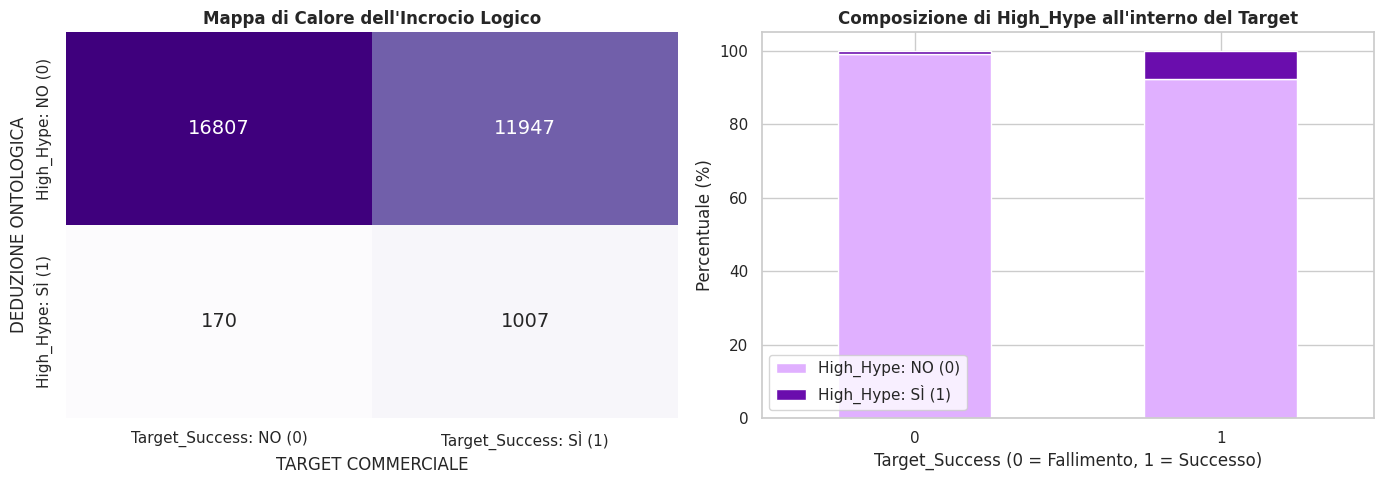

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Caricamento del dataset arricchito per l'analisi incrociata
df_analysis = pd.read_csv("steam_enriched.csv")

# Calcolo della Tabella di Contingenza (Frequenze reali)
tabella_incrocio = pd.crosstab(
    df_analysis['High_Hype'],
    df_analysis['Target_Success'],
    margins=False
)

# Ridenominiamo gli indici per una lettura elegante del grafico
tabella_incrocio.index = ['High_Hype: NO (0)', 'High_Hype: SÌ (1)']
tabella_incrocio.columns = ['Target_Success: NO (0)', 'Target_Success: SÌ (1)']

print(" [TABELLA DI CONTINGENZA REALE (CONTEGGIO GIOCHI)]:")
display(tabella_incrocio)

# 3. Generazione dei Grafici Afiancati
plt.figure(figsize=(14, 5))

# Grafico 1: Heatmap della distribuzione delle frequenze
plt.subplot(1, 2, 1)
sns.heatmap(tabella_incrocio, annot=True, fmt="d", cmap="Purples", cbar=False, annot_kws={"size": 14})
plt.title("Mappa di Calore dell'Incrocio Logico", fontsize=12, fontweight='bold')
plt.ylabel("DEDUZIONE ONTOLOGICA")
plt.xlabel("TARGET COMMERCIALE")

# Grafico 2: Barplot accatastato percentuale per mostrare la composizione
plt.subplot(1, 2, 2)
# Calcoliamo le percentuali condizionate per capire la composizione del successo
tabella_percentuale = pd.crosstab(df_analysis['Target_Success'], df_analysis['High_Hype'], normalize='index') * 100
tabella_percentuale.plot(kind='bar', stacked=True, color=['#e0b0ff', '#6a0dad'], ax=plt.gca())

plt.title("Composizione di High_Hype all'interno del Target", fontsize=12, fontweight='bold')
plt.xlabel("Target_Success (0 = Fallimento, 1 = Successo)")
plt.ylabel("Percentuale (%)")
plt.xticks(rotation=0)
plt.legend(['High_Hype: NO (0)', 'High_Hype: SÌ (1)'], loc='lower left')

plt.tight_layout()
plt.show()

1. **Feature Engineering & Encoding:** Applica il *One-Hot Encoding* (`get_dummies`) sulle colonne categoriche dedotte dall'ontologia e separa i dati in due scenari di test competitivi: **Scenario A** (4 feature primitive/grezze) e **Scenario B** (feature primitive + feature semantiche arricchite dalla KB).
2. **Cross-Validazione iterativa (10 Run):** Configura un ciclo di simulazione a 10 iterazioni indipendenti con campionamento stratificato alternato (`train_test_split` con seed dinamico 80/20) per monitorare la stabilità degli algoritmi contro la varianza del dataset.
3. **Feature scaling vettoriale:** Esegue la standardizzazione z-score (`StandardScaler`) calcolata dinamicamente su ciascun fold per i soli modelli geometrico-metrici (K-NN e Logistic Regression).
4. **Multi-Model Training:** Addestra in parallelo 4 classificatori eterogenei (K-NN, Regressione Logistica, Albero di Decisione, Random Forest) collezionando a ogni run i punteggi di Accuratezza, Precisione e F1-Score.
5. **Consolidamento metrico:** Calcola ed esibisce la tabella comparativa finale aggregando i risultati medi $(\mu)$ e le relative deviazioni standard $(\sigma)$ per evidenziare l'impatto reale dell'iniezione della conoscenza ontologica.

In [34]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Caricamento del dataset arricchito dal motore a regole
df_ml = pd.read_csv("steam_enriched.csv")

# Feature commerciale pura (senza ReviewScore) per evitare Data Leakage
df_ml['High_Hype'] = ((df_ml['PositiveReview'] > 5000) & (df_ml['Price'] < 40.0)).astype(int)

# Preprocessing e codifica delle variabili categoriche estratte dall'ontologia
df_encoded = pd.get_dummies(df_ml, columns=['Monetization_Model', 'Hardware_Tier', 'Commercial_Risk'], drop_first=True)

# Definizione dei due set di feature (scenari di test)
features_raw = ['Price', 'PositiveReview', 'NegativeReview', 'Memory_GB']
kb_cols = [col for col in df_encoded.columns if 'Monetization_Model_' in col or 'Hardware_Tier_' in col or 'Commercial_Risk_' in col] + ['High_Hype']
features_kb = features_raw + kb_cols

# Separazione della variabile obiettivo (Target)
X_raw_full = df_encoded[features_raw].fillna(0)
X_kb_full = df_encoded[features_kb].fillna(0)
y = df_encoded['Target_Success'].fillna(0).astype(int)

# Inizializzazione dei 4 modelli base
models = {
    "K-Nearest Neighbors (K-NN)": KNeighborsClassifier(),
    "Logistic Regression      ": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree Classifier ": DecisionTreeClassifier(random_state=42),
    "Random Forest Classifier ": RandomForestClassifier(random_state=42)
}

# Definizione dello spazio degli iperparametri per la Grid Search
param_grids = {
    "K-Nearest Neighbors (K-NN)": {
        'n_neighbors': [3, 5, 7]
    },
    "Logistic Regression      ": {
        'C': [0.1, 1.0, 10.0]
    },
    "Decision Tree Classifier ": {
        'max_depth': [3, 5, 10],
        'criterion': ['gini', 'entropy']
    },
    "Random Forest Classifier ": {
        'n_estimators': [50, 100],
        'max_depth': [5, 10, None]
    }
}

results = {model_name: {"raw": {"acc": [], "prec": [], "f1": []}, "kb": {"acc": [], "prec": [], "f1": []}} for model_name in models}

print(f"-> Avvio della simulazione su 10 Run indipendenti con Grid Search e Scaler Selettivo...")

for run in range(1, 11):
    current_seed = 42 + run

    X_train_r, X_test_r, y_train, y_test = train_test_split(X_raw_full, y, test_size=0.20, random_state=current_seed, stratify=y)
    X_train_k, X_test_k, _, _ = train_test_split(X_kb_full, y, test_size=0.20, random_state=current_seed, stratify=y)

    # --- SCALER PER SCENARIO RAW ---
    scaler_r = StandardScaler()
    X_train_r_scaled = scaler_r.fit_transform(X_train_r)
    X_test_r_scaled = scaler_r.transform(X_test_r)

    # --- SCALER SELETTIVO PER SCENARIO KB ---
    scaler_k = StandardScaler()
    X_train_k_scaled = X_train_k.copy().values
    X_test_k_scaled = X_test_k.copy().values

    X_train_k_scaled[:, :4] = scaler_k.fit_transform(X_train_k_scaled[:, :4])
    X_test_k_scaled[:, :4] = scaler_k.transform(X_test_k_scaled[:, :4])

    # Addestramento e valutazione
    for model_name, model in models.items():

        # --- Dati Grezzi ---
        grid_raw = GridSearchCV(estimator=model, param_grid=param_grids[model_name], cv=3, scoring='f1', n_jobs=-1)

        if "Neighbors" in model_name or "Regression" in model_name:
            grid_raw.fit(X_train_r_scaled, y_train)
            preds_raw = grid_raw.best_estimator_.predict(X_test_r_scaled)
        else:
            grid_raw.fit(X_train_r, y_train)
            preds_raw = grid_raw.best_estimator_.predict(X_test_r)

        if run == 1:
            print(f"[Run 1] {model_name.strip()} (Grezzo) - Parametri migliori: {grid_raw.best_params_}")

        results[model_name]["raw"]["acc"].append(accuracy_score(y_test, preds_raw))
        results[model_name]["raw"]["prec"].append(precision_score(y_test, preds_raw, zero_division=0))
        results[model_name]["raw"]["f1"].append(f1_score(y_test, preds_raw, zero_division=0))

        # --- Conoscenza ontologica (KB) ---
        grid_kb = GridSearchCV(estimator=model, param_grid=param_grids[model_name], cv=3, scoring='f1', n_jobs=-1)

        if "Neighbors" in model_name or "Regression" in model_name:
            grid_kb.fit(X_train_k_scaled, y_train)
            preds_kb = grid_kb.best_estimator_.predict(X_test_k_scaled)
        else:
            grid_kb.fit(X_train_k, y_train)
            preds_kb = grid_kb.best_estimator_.predict(X_test_k)

        if run == 1:
            print(f"[Run 1] {model_name.strip()} (+KB)     - Parametri migliori: {grid_kb.best_params_}")

        results[model_name]["kb"]["acc"].append(accuracy_score(y_test, preds_kb))
        results[model_name]["kb"]["prec"].append(precision_score(y_test, preds_kb, zero_division=0))
        results[model_name]["kb"]["f1"].append(f1_score(y_test, preds_kb, zero_division=0))

# Generazione Report Finale
riga_report = []
for model_name in models:
    riga_report.append({
        "Modello": model_name.strip(),
        "Accuratezza (Grezzo)": f"{np.mean(results[model_name]['raw']['acc'])*100:.2f}% ± {np.std(results[model_name]['raw']['acc'])*100:.2f}",
        "Accuratezza (+KB)": f"{np.mean(results[model_name]['kb']['acc'])*100:.2f}% ± {np.std(results[model_name]['kb']['acc'])*100:.2f}",
        "F1-Score (Grezzo)": f"{np.mean(results[model_name]['raw']['f1'])*100:.2f}% ± {np.std(results[model_name]['raw']['f1'])*100:.2f}",
        "F1-Score (+KB)": f"{np.mean(results[model_name]['kb']['f1'])*100:.2f}% ± {np.std(results[model_name]['kb']['f1'])*100:.2f}"
    })

df_report = pd.DataFrame(riga_report)
display(df_report)

-> Avvio della simulazione su 10 Run indipendenti con Grid Search e Scaler Selettivo...
[Run 1] K-Nearest Neighbors (K-NN) (Grezzo) - Parametri migliori: {'n_neighbors': 3}
[Run 1] K-Nearest Neighbors (K-NN) (+KB)     - Parametri migliori: {'n_neighbors': 3}
[Run 1] Logistic Regression (Grezzo) - Parametri migliori: {'C': 10.0}
[Run 1] Logistic Regression (+KB)     - Parametri migliori: {'C': 10.0}
[Run 1] Decision Tree Classifier (Grezzo) - Parametri migliori: {'criterion': 'gini', 'max_depth': 10}
[Run 1] Decision Tree Classifier (+KB)     - Parametri migliori: {'criterion': 'gini', 'max_depth': 10}
[Run 1] Random Forest Classifier (Grezzo) - Parametri migliori: {'max_depth': None, 'n_estimators': 100}
[Run 1] Random Forest Classifier (+KB)     - Parametri migliori: {'max_depth': None, 'n_estimators': 100}


,Modello,Accuratezza (Grezzo),Accuratezza (+KB),F1-Score (Grezzo),F1-Score (+KB)
0,K-Nearest Neighbors (K-NN),92.97% ± 0.31,90.74% ± 0.37,91.80% ± 0.39,89.21% ± 0.45
1,Logistic Regression,82.11% ± 0.64,82.17% ± 0.58,74.05% ± 1.15,74.14% ± 1.05
2,Decision Tree Classifier,97.52% ± 0.15,97.52% ± 0.15,97.16% ± 0.17,97.16% ± 0.17
3,Random Forest Classifier,99.28% ± 0.08,98.22% ± 0.16,99.17% ± 0.09,97.96% ± 0.18


1. **Discretizzazione del dataset:** casting a stringa delle 5 feature necessarie per il calcolo probabilistico condizionato.
2. **Definizione della topologia causale (DAG):** Costruisce un Grafo Diretto Aciclico connettendo i nodi sorgente (`Monetization_Model`, `Hardware_Tier`, `High_Hype`) verso i nodi dipendenti, mappando le relazioni di causa-effetto fino al `Target_Success`.
3. **Stima dei parametri:** Calcola le tabelle di probabilità pondizionata su tutte le ~30.000 righe sfruttando l'estimatore di massima verosimiglianza (`MaximumLikelihoodEstimator`).
4. **Motore di inferenza esatta:** Inizializza l'algoritmo di eliminazione delle variabili (`VariableElimination`) per ottimizzare il calcolo esatto delle distribuzioni a posteriori eliminando i nodi latenti non osservati.
5. **Simulazione Multi-Scenario (What-If Analysis):** Interroga simultaneamente la rete su 4 differenti profili di mercato (dal blockbuster AAA all'indie di nicchia), calcolando per ciascuno l'esatta probabilità di successo condizionata dall'evidenza introdotta nel sistema.
6. **Inferenza diagnostica inversa**: Ribalta la direzione del ragionamento causale impostando come evidenza fissa lo stato finale del mercato (`Target_Success`). Interrogando la rete all'indietro (dagli effetti alle cause), il sistema isola i titoli di successo o di fallimento per analizzare ex-post la distribuzione di probabilità dei loro profili di rischio e di hype.
7. **Ragionamento intermedio e spiegazione delle anomalie (*{Explaining Away}*)**: Sfrutta la propagazione locale delle probabilità sia per misurare l'impatto isolato tra nodi intermedi (es. come i requisiti hardware condizionino il rischio a prescindere dal successo), sia per diagnosticare anomalie di mercato, identificando la causa del fallimento di prodotti teoricamente avvantaggiati (come i titoli gratuiti).

In [35]:
!pip install pgmpy
import time
import warnings
import numpy as np
import pandas as pd
import pgmpy.models
import pgmpy.estimators
import pgmpy.inference

warnings.filterwarnings('ignore')

# Preparazione del dataset discreto
df_bayes = pd.DataFrame()
df_bayes['Monetization_Model'] = df_ml['Monetization_Model'].astype(str)
df_bayes['Hardware_Tier'] = df_ml['Hardware_Tier'].astype(str)
df_bayes['Commercial_Risk'] = df_ml['Commercial_Risk'].astype(str)
df_bayes['High_Hype'] = df_ml['High_Hype'].astype(str)
df_bayes['Target_Success'] = df_ml['Target_Success'].astype(str)

# Struttura causale del grafo (DAG)
steam_bn = pgmpy.models.DiscreteBayesianNetwork([
    ('Monetization_Model', 'Commercial_Risk'),
    ('Hardware_Tier', 'Commercial_Risk'),
    ('Commercial_Risk', 'Target_Success'),
    ('High_Hype', 'Target_Success')
])

# Calcolo delle tabelle di probabilità condizionata (CPT)
mle = pgmpy.estimators.MaximumLikelihoodEstimator(model=steam_bn, data=df_bayes)
for cpd in mle.get_parameters():
    steam_bn.add_cpds(cpd)

# Configurazione del motore di inferenza esatta
exact_engine = pgmpy.inference.VariableElimination(steam_bn)


scenari = {
    "Scenario 1: Il alockbuster acclamato (Tripla A)": {
        'Monetization_Model': 'Premium_Paid',
        'Hardware_Tier': 'High_End_Specs',
        'High_Hype': '1'
    },
    "Scenario 2: Il tripla A al Lancio (Flop di Critica)": {
        'Monetization_Model': 'Premium_Paid',
        'Hardware_Tier': 'High_End_Specs',
        'High_Hype': '0'
    },
    "Scenario 3: Il fenomeno Free-To-Play leggero (Es. Casual/Esport)": {
        'Monetization_Model': 'Free_To_Play',
        'Hardware_Tier': 'Standard_Specs',
        'High_Hype': '1'
    },
    "Scenario 4: L'indie di nicchia a pagamento (grafica semplice)": {
        'Monetization_Model': 'Premium_Paid',
        'Hardware_Tier': 'Standard_Specs',
        'High_Hype': '0'
    }
}

print("-> Esecuzione delle query probabilistiche sui diversi profili commerciali...")

for nome_scenario, evidenze in scenari.items():
    print("\n" + "="*70)
    print(f" {nome_scenario}")
    print("="*70)
    print(f"Evidenze impostate: {evidenze}")

    # Calcolo della probabilità posteriore
    risultato = exact_engine.query(variables=['Target_Success'], evidence=evidenze, show_progress=False)
    print(risultato)

    query_rischio = exact_engine.query(
    variables=['Commercial_Risk'],
    evidence={'Target_Success': '1'},
    show_progress=False
)
print("-> Profilo di RISCHIO COMMERCIALE dei giochi che hanno avuto SUCCESSO:")
print(query_rischio)

query_hype = exact_engine.query(
    variables=['High_Hype'],
    evidence={'Target_Success': '0'},
    show_progress=False
)
print("\n-> Probabilità di avere HIGH HYPE tra i giochi che hanno FLOPPATO:")
print(query_hype)

query_rischio_tecnico = exact_engine.query(
    variables=['Commercial_Risk'],
    evidence={'Hardware_Tier': 'High_End_Specs'},
    show_progress=False
)
print("\n-> Distribuzione del RISCHIO COMMERCIALE per i soli titoli HARDWARE HIGH-END:")
print(query_rischio_tecnico)

query_diagnostica_flop = exact_engine.query(
    variables=['High_Hype'],
    evidence={'Target_Success': '0', 'Monetization_Model': 'Free_To_Play'},
    show_progress=False
)
print("\n-> Probabilità di HIGH HYPE per un titolo FREE-TO-PLAY che ha FLOPPATO:")
print(query_diagnostica_flop)

-> Esecuzione delle query probabilistiche sui diversi profili commerciali...

 Scenario 1: Il alockbuster acclamato (Tripla A)
Evidenze impostate: {'Monetization_Model': 'Premium_Paid', 'Hardware_Tier': 'High_End_Specs', 'High_Hype': '1'}
+-------------------+-----------------------+
| Target_Success    |   phi(Target_Success) |
+===================+=======================+
| Target_Success(0) |                0.1517 |
+-------------------+-----------------------+
| Target_Success(1) |                0.8483 |
+-------------------+-----------------------+

 Scenario 2: Il tripla A al Lancio (Flop di Critica)
Evidenze impostate: {'Monetization_Model': 'Premium_Paid', 'Hardware_Tier': 'High_End_Specs', 'High_Hype': '0'}
+-------------------+-----------------------+
| Target_Success    |   phi(Target_Success) |
+===================+=======================+
| Target_Success(0) |                0.5847 |
+-------------------+-----------------------+
| Target_Success(1) |                0.4153